In [1]:
# pip install pandas numpy scikit-learn seaborn matplotlib
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay,
                             PrecisionRecallDisplay)
sns.set_theme(context='notebook', style='whitegrid')
np.random.seed(0)

In [2]:
#Load data (Seaborn) and basic peek
df = sns.load_dataset('titanic').drop(columns=['alive'])  # drop redundant label
df.head(), df.shape, df.isna().sum().sort_values(ascending=False).head(10)

(   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
 0         0       3    male  22.0      1      0   7.2500        S  Third   
 1         1       1  female  38.0      1      0  71.2833        C  First   
 2         1       3  female  26.0      0      0   7.9250        S  Third   
 3         1       1  female  35.0      1      0  53.1000        S  First   
 4         0       3    male  35.0      0      0   8.0500        S  Third   
 
      who  adult_male deck  embark_town  alone  
 0    man        True  NaN  Southampton  False  
 1  woman       False    C    Cherbourg  False  
 2  woman       False  NaN  Southampton   True  
 3  woman       False    C  Southampton  False  
 4    man        True  NaN  Southampton   True  ,
 (891, 14),
 deck           688
 age            177
 embarked         2
 embark_town      2
 pclass           0
 survived         0
 parch            0
 sibsp            0
 sex              0
 fare             0
 dtype: int64)

In [3]:
#Choose features & define X/y
features = ['pclass','sex','age','sibsp','parch','fare','embarked']
df_model = df[features + ['survived']].copy()

# Quick missingness handling for age/embarked/fare
df_model['embarked'] = df_model['embarked'].fillna(df_model['embarked'].mode().iloc[0])
df_model['fare']     = df_model['fare'].fillna(df_model['fare'].median())
# We'll impute age in the pipeline (median)
X = df_model.drop(columns=['survived'])
y = df_model['survived'].astype(int)

In [4]:
#Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [6]:
#Preprocessing + Logistic Regression (pipeline)
"""Numeric: median impute + standardize

Categorical: most‑frequent impute + one‑hot (ignore unknowns)

Estimator: LogisticRegression with max_iter=1000

(Optionally) class_weight='balanced' if classes are skewed."""
from sklearn.impute import SimpleImputer

num_feats = X.select_dtypes(include='number').columns.tolist()       # ['pclass','age','sibsp','parch','fare']
cat_feats = X.select_dtypes(exclude='number').columns.tolist()       # ['sex','embarked']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler())
        ]), num_feats),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_feats),
    ],
    remainder='drop'
)

clf = Pipeline([
    ('prep', preprocess),
    ('logit', LogisticRegression(max_iter=1000, n_jobs=None))  # add class_weight='balanced' if needed
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

Accuracy=0.771  Precision=0.711  Recall=0.686  F1=0.698  ROC-AUC=0.841
              precision    recall  f1-score   support

        died       0.81      0.82      0.82       137
    survived       0.71      0.69      0.70        86

    accuracy                           0.77       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.77      0.77       223



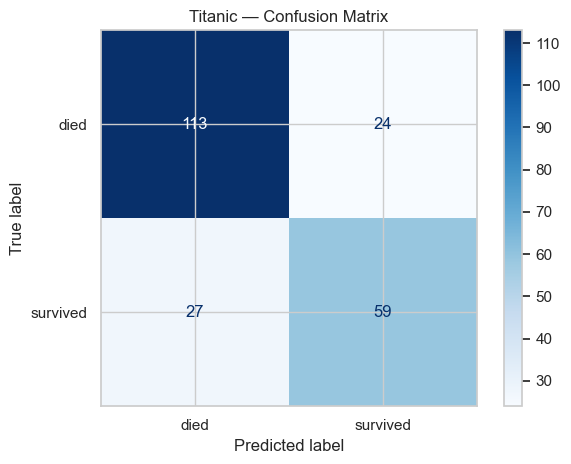

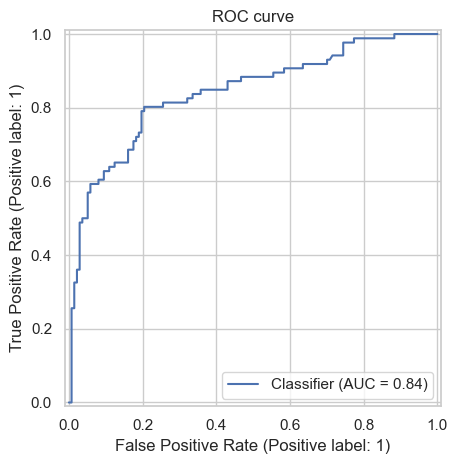

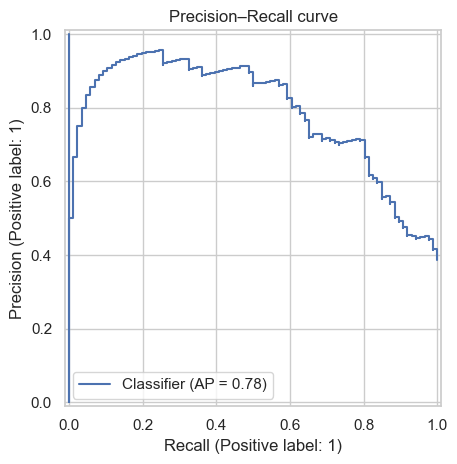

In [7]:
## Evaluate (test set)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  ROC-AUC={auc:.3f}")
print(classification_report(y_test, y_pred, target_names=['died','survived']))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['died','survived']).plot(cmap='Blues')
plt.title('Titanic — Confusion Matrix'); plt.tight_layout(); plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC curve'); plt.tight_layout(); plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title('Precision–Recall curve'); plt.tight_layout(); plt.show()

In [8]:
#Cross‑validation (on full data, for reference)
cv_auc = cross_val_score(clf, X, y, scoring='roc_auc', cv=5)
print("5‑fold ROC‑AUC:", round(cv_auc.mean(),3), "±", round(cv_auc.std(),3))

5‑fold ROC‑AUC: 0.848 ± 0.015


In [11]:
# (Optional) Threshold tuning
#Default threshold is 0.5; you can shift it to trade precision vs recall.
thr = 0.35
y_cut = (y_proba >= thr).astype(int)
print("At threshold", thr, "→",
      classification_report(y_test, y_cut, target_names=['died','survived']))

At threshold 0.35 →               precision    recall  f1-score   support

        died       0.86      0.74      0.80       137
    survived       0.67      0.81      0.73        86

    accuracy                           0.77       223
   macro avg       0.77      0.78      0.77       223
weighted avg       0.79      0.77      0.77       223



In [12]:
"""(Optional) Inspect feature effects (global)
For logistic regression, positive coefficients increase odds of survival."""
# Recover feature names after preprocessing
oh = clf.named_steps['prep'].named_transformers_['cat'].named_steps['oh']
cat_names = oh.get_feature_names_out(cat_feats)
feat_names = np.r_[num_feats, cat_names]

coefs = clf.named_steps['logit'].coef_.ravel()
coef_df = (pd.DataFrame({'feature': feat_names, 'coef': coefs})
           .sort_values('coef', ascending=False))
coef_df.head(10), coef_df.tail(10)

(      feature      coef
 5  sex_female  1.290976
 8  embarked_Q  0.294286
 4        fare  0.128981
 7  embarked_C  0.018676
 3       parch -0.032962
 2       sibsp -0.252851
 9  embarked_S -0.334579
 1         age -0.527969
 0      pclass -0.928047
 6    sex_male -1.312592,
       feature      coef
 5  sex_female  1.290976
 8  embarked_Q  0.294286
 4        fare  0.128981
 7  embarked_C  0.018676
 3       parch -0.032962
 2       sibsp -0.252851
 9  embarked_S -0.334579
 1         age -0.527969
 0      pclass -0.928047
 6    sex_male -1.312592)

In [13]:
#Save model & preprocessing
import joblib
joblib.dump(clf, 'titanic_logreg_pipeline.joblib')

['titanic_logreg_pipeline.joblib']

In [15]:
# Add more features (who, adult_male, deck), retrain, and report improvement
ext_features = features + ['who','adult_male','deck']
# Build df_ext from original dataframe (df) because df_model did not include the new cols
df_ext = df[ext_features + ['survived']].copy()
# Handle simple missingness for 'deck' (most frequent)
df_ext['deck'] = df_ext['deck'].fillna(df_ext['deck'].mode().iloc[0])
# Other missingness (e.g. age) will be imputed in the pipeline
X_ext = df_ext.drop(columns=['survived'])
y_ext = df_ext['survived'].astype(int)

# Train/test split (same seed/stratify for fair comparison)
X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext, y_ext, test_size=0.25, random_state=42, stratify=y_ext
)

# Recompute numeric/categorical feature lists for the extended set
num_feats_ext = X_ext.select_dtypes(include='number').columns.tolist()
cat_feats_ext = X_ext.select_dtypes(exclude='number').columns.tolist()

from sklearn.impute import SimpleImputer

preprocess_ext = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler())
        ]), num_feats_ext),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_feats_ext),
    ],
    remainder='drop'
)

clf_ext = Pipeline([('prep', preprocess_ext), ('logit', LogisticRegression(max_iter=1000, n_jobs=None))])
clf_ext.fit(X_ext_train, y_ext_train)

# Predictions & metrics
y_ext_pred = clf_ext.predict(X_ext_test)
y_ext_proba = clf_ext.predict_proba(X_ext_test)[:,1]
acc_ext = accuracy_score(y_ext_test, y_ext_pred)
auc_ext = roc_auc_score(y_ext_test, y_ext_proba)
print(f"Extended features — Accuracy={acc_ext:.3f}  ROC-AUC={auc_ext:.3f}")
print(classification_report(y_ext_test, y_ext_pred, target_names=['died','survived']))

# Compare to previous AUC (variable `auc` computed earlier)
try:
    delta = auc_ext - auc
    print('Delta AUC:', round(delta,4))
    if delta > 0:
        print('AUC improved ✅')
    elif delta == 0:
        print('AUC unchanged')
    else:
        print('AUC decreased ❌')
except NameError:
    print('Original AUC not found in notebook scope; cannot compare.')

# Save extended pipeline
joblib.dump(clf_ext, 'titanic_logreg_pipeline_ext.joblib')


Extended features — Accuracy=0.807  ROC-AUC=0.854
              precision    recall  f1-score   support

        died       0.84      0.85      0.84       137
    survived       0.76      0.73      0.75        86

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.80       223
weighted avg       0.81      0.81      0.81       223

Delta AUC: 0.0126
AUC improved ✅


['titanic_logreg_pipeline_ext.joblib']

In [16]:
# Set class_weight='balanced' and compare recall for 'survived' at 0.5 threshold
from sklearn.metrics import recall_score
thr = 0.5

# Original features: balanced classifier
clf_bal = Pipeline([('prep', preprocess), ('logit', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf_bal.fit(X_train, y_train)
y_bal_pred = (clf_bal.predict_proba(X_test)[:,1] >= thr).astype(int)
recall_bal = recall_score(y_test, y_bal_pred, pos_label=1)
print(f"Original features + class_weight='balanced' → Recall(survived) = {recall_bal:.3f}")

# Extended features: balanced classifier
clf_ext_bal = Pipeline([('prep', preprocess_ext), ('logit', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf_ext_bal.fit(X_ext_train, y_ext_train)
y_ext_bal_pred = (clf_ext_bal.predict_proba(X_ext_test)[:,1] >= thr).astype(int)
recall_ext_bal = recall_score(y_ext_test, y_ext_bal_pred, pos_label=1)
print(f"Extended features + class_weight='balanced' → Recall(survived) = {recall_ext_bal:.3f}")

# Compare to unbalanced models (if available in scope)
try:
    y_orig_unbal = (clf.predict_proba(X_test)[:,1] >= thr).astype(int)
    recall_orig_unbal = recall_score(y_test, y_orig_unbal, pos_label=1)
    print(f"Original (no class_weight) → Recall(survived) = {recall_orig_unbal:.3f}")
    print(f"Change in recall (balanced - unbalanced) = {recall_bal - recall_orig_unbal:+.3f}")
except Exception:
    pass

try:
    y_ext_unbal = (clf_ext.predict_proba(X_ext_test)[:,1] >= thr).astype(int)
    recall_ext_unbal = recall_score(y_ext_test, y_ext_unbal, pos_label=1)
    print(f"Extended (no class_weight) → Recall(survived) = {recall_ext_unbal:.3f}")
    print(f"Change in recall (balanced - unbalanced) = {recall_ext_bal - recall_ext_unbal:+.3f}")
except Exception:
    pass


Original features + class_weight='balanced' → Recall(survived) = 0.802
Extended features + class_weight='balanced' → Recall(survived) = 0.791
Original (no class_weight) → Recall(survived) = 0.686
Change in recall (balanced - unbalanced) = +0.116
Extended (no class_weight) → Recall(survived) = 0.733
Change in recall (balanced - unbalanced) = +0.058


In [17]:
# Tune classification threshold to reach recall ≥ 0.80 (maximize F1 subject to that)
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def tune_threshold(y_true, y_proba, min_recall=0.8, n_steps=501):
    thrs = np.linspace(0, 1, n_steps)
    best_candidate = None
    best_f1 = -1
    # First: find thresholds meeting min_recall and pick highest F1
    for t in thrs:
        y_pred = (y_proba >= t).astype(int)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if r >= min_recall and f1 > best_f1:
            best_f1 = f1
            best_candidate = (t, r, f1, precision_score(y_true, y_pred, zero_division=0), accuracy_score(y_true, y_pred))
    if best_candidate is not None:
        return (*best_candidate, True)
    # If none meet min_recall, return threshold with max recall (tie-breaker: max F1)
    best_r = -1
    best_tuple = None
    for t in thrs:
        y_pred = (y_proba >= t).astype(int)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if r > best_r or (r == best_r and (best_tuple is None or f1 > best_tuple[2])):
            best_r = r
            best_tuple = (t, r, f1, precision_score(y_true, y_pred, zero_division=0), accuracy_score(y_true, y_pred))
    return (*best_tuple, False)

# Tune for original model (if available)
try:
    y_proba_orig = clf.predict_proba(X_test)[:, 1]
    thr, rec, f1s, prec, acc, satisfied = tune_threshold(y_test, y_proba_orig, min_recall=0.8)
    print('Original model — chosen threshold:', round(thr, 3))
    print(f"Precision={prec:.3f}  Recall={rec:.3f}  F1={f1s:.3f}  Accuracy={acc:.3f}")
    if satisfied:
        print('Reached recall >= 0.80')
    else:
        print('Could not reach recall >= 0.80; returned threshold maximizing recall')
except Exception as e:
    print('Original model tuning skipped:', e)

# Tune for extended model (if available)
try:
    y_proba_ext = clf_ext.predict_proba(X_ext_test)[:, 1]
    thr_e, rec_e, f1_e, prec_e, acc_e, satisfied_e = tune_threshold(y_ext_test, y_proba_ext, min_recall=0.8)
    print('\nExtended model — chosen threshold:', round(thr_e, 3))
    print(f"Precision={prec_e:.3f}  Recall={rec_e:.3f}  F1={f1_e:.3f}  Accuracy={acc_e:.3f}")
    if satisfied_e:
        print('Reached recall >= 0.80')
    else:
        print('Could not reach recall >= 0.80; returned threshold maximizing recall')
except Exception as e:
    print('Extended model tuning skipped:', e)


Original model — chosen threshold: 0.406
Precision=0.711  Recall=0.802  F1=0.754  Accuracy=0.798
Reached recall >= 0.80

Extended model — chosen threshold: 0.304
Precision=0.692  Recall=0.837  F1=0.758  Accuracy=0.794
Reached recall >= 0.80


In [18]:
# Add PolynomialFeatures (degree=2) to numeric columns only and evaluate with CV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score

# Recompute numeric/categorical lists (safe)
num_feats = X.select_dtypes(include='number').columns.tolist()
cat_feats = X.select_dtypes(exclude='number').columns.tolist()

preprocess_poly = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('sc', StandardScaler())
        ]), num_feats),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_feats),
    ],
    remainder='drop'
)

pipe_poly = Pipeline([('prep', preprocess_poly), ('logit', LogisticRegression(max_iter=1000))])

# 5-fold CV AUC on full dataset
cv_base = cross_val_score(clf, X, y, scoring='roc_auc', cv=5)
cv_poly = cross_val_score(pipe_poly, X, y, scoring='roc_auc', cv=5)
print('Base 5-fold ROC-AUC: ', round(cv_base.mean(),3), '±', round(cv_base.std(),3))
print('Poly 5-fold ROC-AUC: ', round(cv_poly.mean(),3), '±', round(cv_poly.std(),3))

# Fit on training split and evaluate on test split to check for overfitting
pipe_poly.fit(X_train, y_train)
y_poly_proba_test = pipe_poly.predict_proba(X_test)[:,1]
auc_poly_test = roc_auc_score(y_test, y_poly_proba_test)

# Train AUC for poly
y_poly_proba_train = pipe_poly.predict_proba(X_train)[:,1]
auc_poly_train = roc_auc_score(y_train, y_poly_proba_train)

print('\nBase test ROC-AUC:', round(auc,3) if 'auc' in globals() else 'n/a')
print('Poly test ROC-AUC:', round(auc_poly_test,3))
print('Poly train ROC-AUC:', round(auc_poly_train,3))

gap = auc_poly_train - auc_poly_test
if gap > 0.05:
    print('Warning: possible overfitting (train-test AUC gap > 0.05)')
else:
    print('No major overfitting detected (train-test AUC gap ≤ 0.05)')

# Short recommendation
if cv_poly.mean() > cv_base.mean():
    print('\nPolynomial features improved CV AUC on average.')
else:
    print('\nPolynomial features did not improve CV AUC on average.')

# (Optional) save pipeline with polynomial features
import joblib
joblib.dump(pipe_poly, 'titanic_logreg_pipeline_poly.joblib')


Base 5-fold ROC-AUC:  0.848 ± 0.015
Poly 5-fold ROC-AUC:  0.86 ± 0.023

Base test ROC-AUC: 0.841
Poly test ROC-AUC: 0.849
Poly train ROC-AUC: 0.878
No major overfitting detected (train-test AUC gap ≤ 0.05)

Polynomial features improved CV AUC on average.


['titanic_logreg_pipeline_poly.joblib']